In [133]:
import numpy as np
import healpy as hp
import pymaster as nmt
from matplotlib import pyplot as plt

from simulate_planck_maps import simulate_planck_maps
from compute_cl import compute_cl
from compute_weights import compute_weights
from compute_alm_ilc import compute_alm_ilc
from compute_decoupled_cl import compute_decoupled_cl
from compute_decoupled_cl_2 import compute_decoupled_cl_2
from mask_maps import mask_maps

%matplotlib inline

In [134]:
nside=128
npix=hp.nside2npix(nside=nside)
freq = np.array([28.4,  44.1,  70.4,  100.0,  143.0,  217.0,  353.0])
n_freqs = len(freq)

Simulate maps using PySM

In [135]:
noise, dust, sync, ff, cmb = simulate_planck_maps(nside)

Combining the CMB and foreground maps to be input into ILC

In [136]:
maps_pl = cmb + noise + dust + sync + ff #cmb and foregrounds combined
fgds_pl= dust + sync + ff #combined foregrounds

Transforimng frequency maps to harmonic space by decomposition

In [137]:
#transform maps to spherical harmonics
lmax=3*nside -1 #default is lmax= 3*nside+1
alm_size=hp.Alm.getsize(lmax)
alm_maps=np.zeros((n_freqs, alm_size), dtype=complex) #storing coefficients in an array of dim n_freqs*almsize. dtype is complex to account for -ive values
alm_fgds= np.zeros((n_freqs, alm_size), dtype=complex)
for nf in range(n_freqs):
    alm_maps[nf,:]= hp.map2alm(maps_pl[nf,:], lmax=lmax, mmax=None, iter=0, pol=False) #record alm corresponding to each f for a corresponding l and m
    alm_fgds[nf,:]= hp.map2alm(fgds_pl[nf,:], lmax=lmax, mmax=None, iter=0, pol=False)

Computing the angular power spectrum for the unmasked data

In [138]:
alm_p, C_l=compute_cl(alm_maps, lmax, n_freqs)
print(alm_p.shape)
print(C_l.shape)

(7, 384)
(384, 7, 7)


generating mask

In [139]:
gal_cut = np.radians(10) #galactic latitutde of 10 degrees
cut = np.zeros(npix, dtype=np.float64)
cut[hp.query_strip(nside, np.pi/2-gal_cut, np.pi/2+gal_cut)] = 1 #10 degrees above and below the galactic plane

mask = np.clip(hp.smoothing(cut, fwhm=np.radians(10)), 0, None) #apodizing

print(cut.shape)

(196608,)


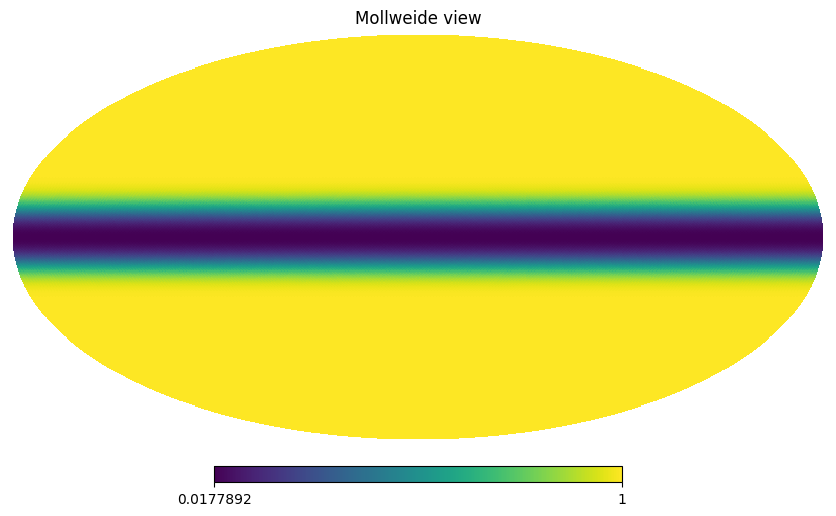

In [140]:
hp.mollview(1-mask)

Decoupled power spectra $\hat{C_l^{ij}} = M_{ll'}^{-1} \tilde{C}_l^{ij}$

where $\tilde{C}_l^{ij}$ is the pseudo power spectrum aka the masked power spectrum

In [141]:
pcl, mcm, cl_dec=compute_decoupled_cl(maps_pl, mask, nside, lmax, n_freqs)
print(mcm.shape)
print(cl_dec.shape)

(384, 384)
(384, 7, 7)


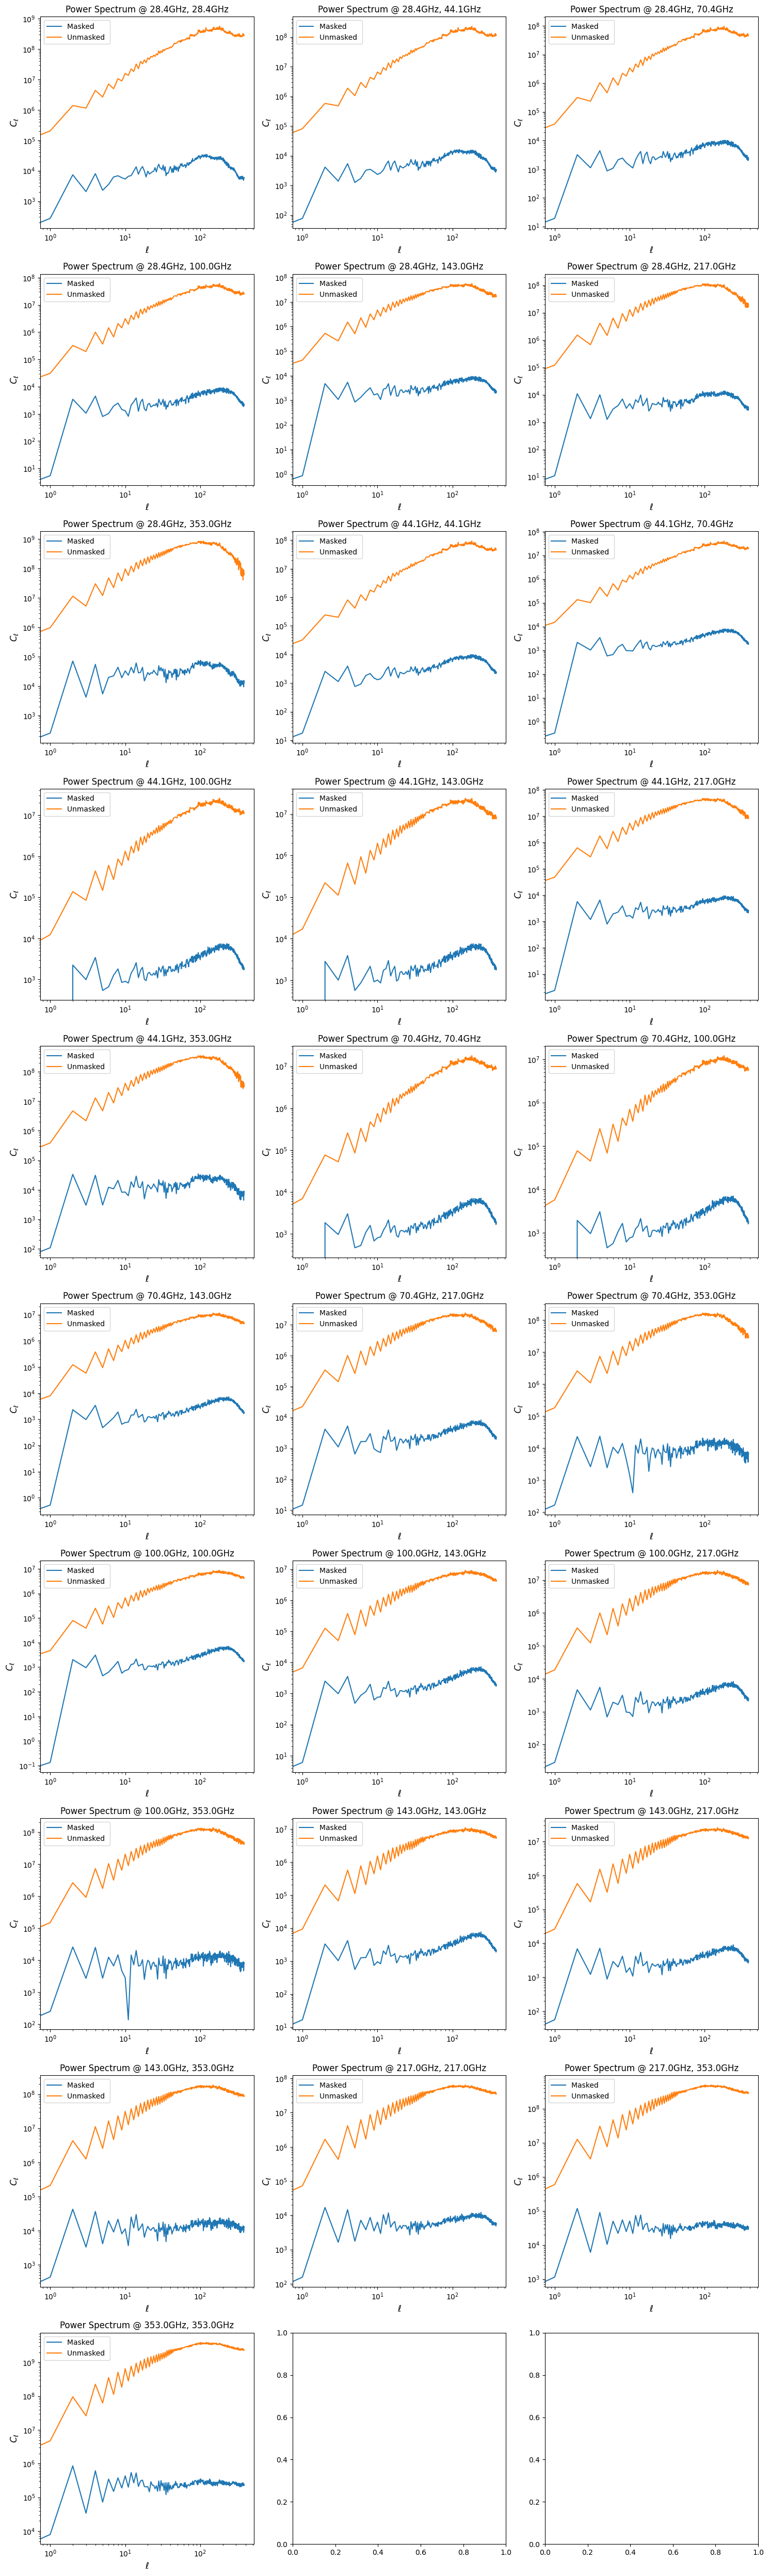

In [142]:
ells = np.arange(lmax+1)
norm = (ells * (ells + 1)) / (2 * np.pi)

n_rows = int(np.ceil(n_freqs * (n_freqs + 1) / (2 * 3)))  # Calculate number of rows for 3 columns

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))  # Create subplots with 3 columns
axes = axes.flatten()  # Flatten in case of 2D axes array

plot_idx = 0  # Track subplot index

# Loop through each frequency pair and plot
for i in range(n_freqs):
    for j in range(i, n_freqs):
        ax = axes[plot_idx]  # Select subplot
        ax.plot(ells, norm * cl_dec[:, i, j], label=f'Masked ') #({freq[i]},{freq[j]})
        ax.plot(ells, norm * C_l[:, i, j], label=f'Unmasked ') #({freq[i]},{freq[j]})
        ax.set_xlabel('$\\ell$', fontsize=12)
        ax.set_ylabel('$C_\\ell$', fontsize=12)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.legend(fontsize=10)
        ax.set_title(f"Power Spectrum @ {freq[i]}GHz, {freq[j]}GHz")

        plot_idx += 1  # Move to next subplot
plt.tight_layout()  # Adjust layout for clarity
plt.show()

Computing the decoupled power spectrum of the masked CMB map

In [143]:
pcl_cmb, mcm_cmb, cmb_dec= compute_decoupled_cl(cmb, mask, nside, lmax, n_freqs)

In [144]:

Cl_cmb = hp.anafast(cmb[0]) #input cmb map

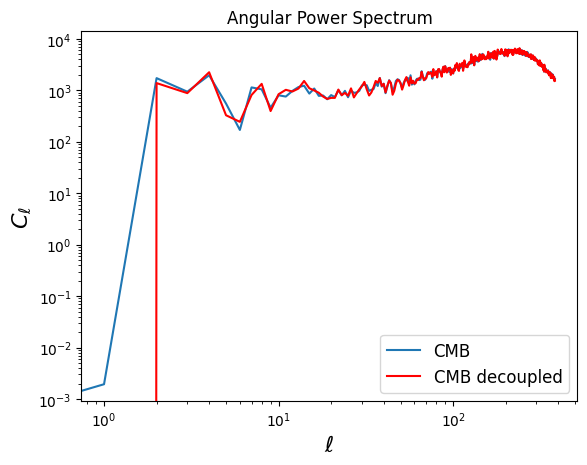

In [145]:


plt.plot(ells, norm*Cl_cmb, label='CMB')
plt.plot(ells, norm*cmb_dec[:,0,0], 'r-',label= 'CMB decoupled')
#plt.plot(ells, norm*cl_dec[:,4,3], 'g-',label= 'Decoupled Cl')
plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.xscale("log")
plt.yscale("log")
plt.legend(fontsize=12)
plt.title("Angular Power Spectrum")
plt.show()

Mode Coupling Matrix

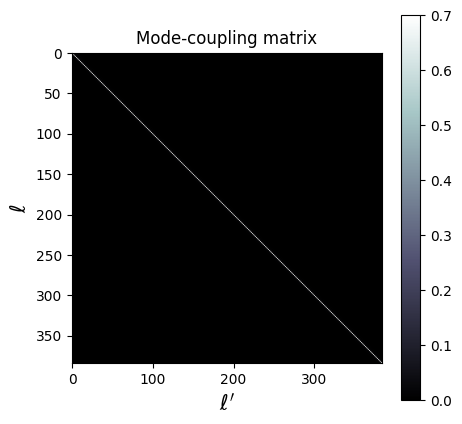

In [146]:
# Plot MCM
plt.figure(figsize=(5, 5))
plt.title('Mode-coupling matrix')
plt.imshow(mcm, cmap='bone')
#plt.plot(mcm[:,30])
plt.ylabel("$\\ell$", fontsize=15)
plt.xlabel("$\\ell'$", fontsize=15)
plt.colorbar()
plt.show()


Now we can compute the inverse covariance matrix and compute the weights using $$\omega_i(l) = \frac{\sum_j (C_l^{-1})_{ij} b_{j}}{\sum_{ij}b_i (C_l^{-1})_{ij} b_{j}}$$

where $b_i $ represents the CMB transfer function. $b_i = [1,...,1]$

In [147]:
cl_inv, weights = compute_weights(n_freqs, lmax, cl_dec)
print(cl_inv.shape)
print(weights.shape) #nf x m array

(7, 7)
(7, 384)


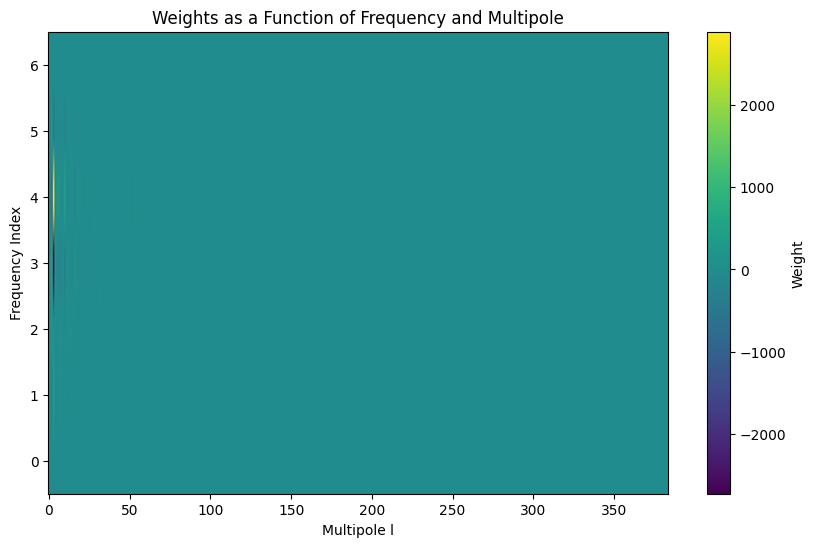

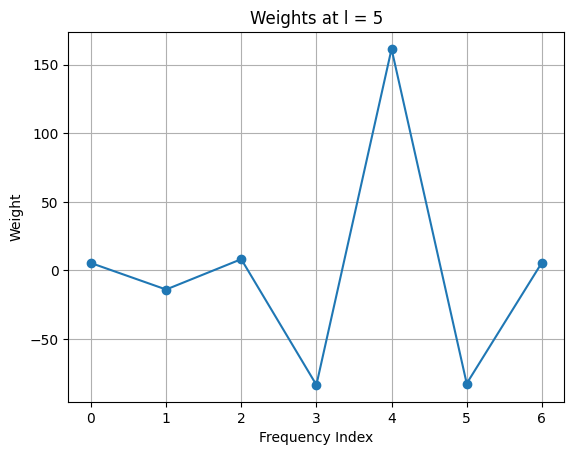

In [148]:
plt.figure(figsize=(10, 6))
plt.imshow(weights[:,:], aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(label="Weight")
plt.xlabel("Multipole l")
plt.ylabel("Frequency Index")
#plt.xlim(50,)
plt.title("Weights as a Function of Frequency and Multipole")
plt.show()


plt.plot(range(n_freqs), weights[:, 5], marker='o', linestyle='-')

plt.xlabel("Frequency Index")
plt.ylabel("Weight")
plt.title(f"Weights at l = {5}")
plt.grid()

Masking the data and converting the masked maps to harmonic space

In [149]:
maps_masked, alm_masked= mask_maps(maps_pl, mask, alm_size,lmax, n_freqs, npix)
print(maps_masked.shape)

(7, 196608)


Applying the weights to the masked data

$$a^{ILC}_{lm} = \sum_i w_i(l)a^i_{lm}$$

In [150]:
alm_ilc=compute_alm_ilc(alm_masked, alm_size, weights, lmax)
print(alm_ilc.shape)

(73920,)


Converting back to pixel space

In [151]:
maps_out = hp.alm2map(alm_ilc, nside, lmax=lmax, mmax=None)
print(maps_out.shape)

(196608,)


Computing the angular power spectrum of the masked, component separated map

In [152]:
pcl_hilc, mcm_hilc, cl_hilc=compute_decoupled_cl_2(maps_out, mask, nside, lmax, n_freqs) 
#for error ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.
#make sure to return ALL outputs of function

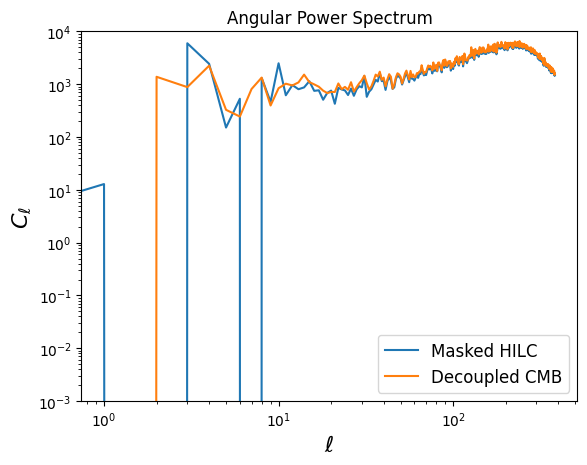

In [153]:
#plt.plot(ells, (norm*cl_dec[:,5,3]), label='Decoupled Cl')
plt.plot(ells, norm*cl_hilc, label='Masked HILC')
plt.plot(ells, norm*cmb_dec[:,0,0], label='Decoupled CMB')
#plt.plot(ells, norm*hilc, 'r-',label= 'biased hilc')
plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.xscale("log")
plt.yscale("log")
plt.ylim(1e-3,1e+4)
plt.legend(fontsize=12)
plt.title("Angular Power Spectrum")
plt.show()

Compute the fractional difference between the two spectra:

$$
\text{frac\_diff}(\ell) = \frac{C_{\ell}^{\text{Decoupled}} - C_{\ell}^{\text{Input}}}{C_{\ell}^{\text{Input}}}
$$


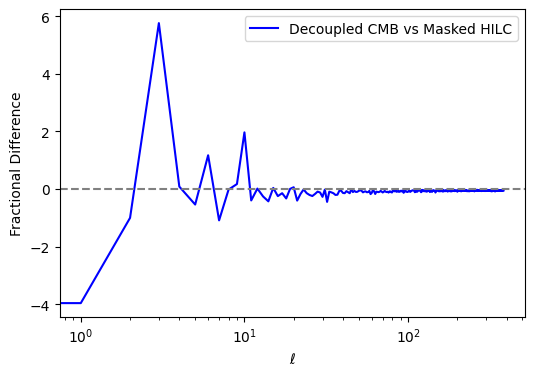

In [154]:
#frac_diff = (cmb_dec[:,0,0] - Cl_cmb) / Cl_cmb  # Avoid division by zero
diff = (cl_hilc - cmb_dec[:,0,0]) / cmb_dec [:,0,0]

plt.figure(figsize=(6, 4))
#plt.plot(ells, frac_diff, label="input CMB vs Decoupled CMB", color="black")
plt.plot(ells, diff, label="Decoupled CMB vs Masked HILC", color="blue")
plt.axhline(0, linestyle="--", color="gray")  # Reference line
#plt.yscale("log")
#plt.ylim(-2500, 500)
plt.xscale("log")
plt.xlabel(r"$\ell$")
plt.ylabel(r"Fractional Difference")
#plt.title("Fractional Difference")
plt.legend()
plt.show()

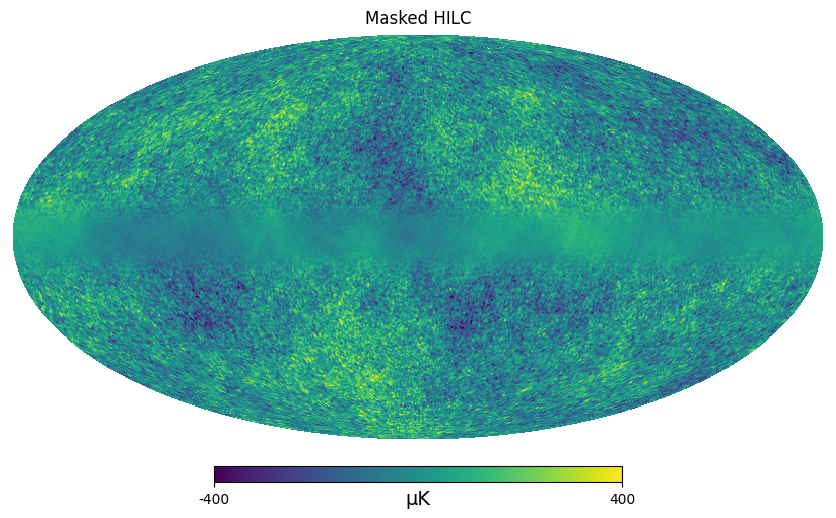

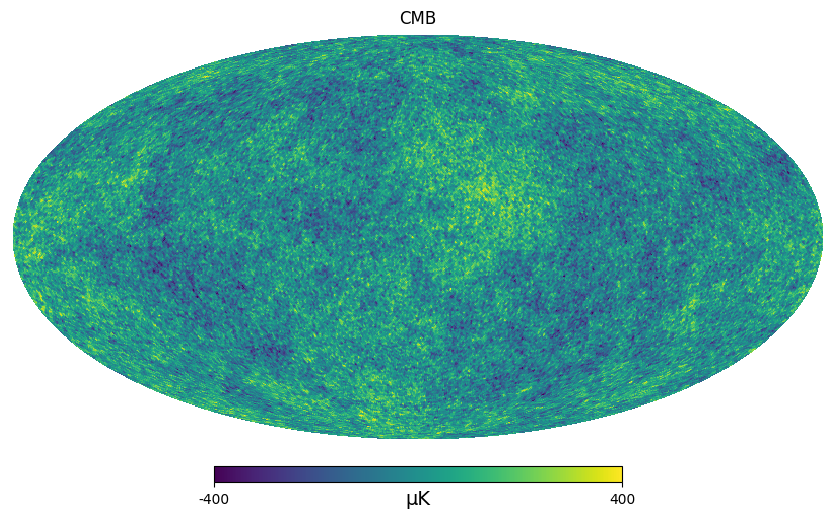

In [155]:
ilc =maps_out-np.mean(maps_out)
#hp.mollview(maps_out, title= "HILC masked", min=-400, max=400)
hp.mollview(ilc, title= "Masked HILC", min=-400, max=400, unit="μK")
hp.mollview(cmb[0],title ="CMB", min=-400, max=400, unit="μK")
#hp.mollview(maps_pl[4], title="Original Map with Foregrounds", min=-400, max=400) #comparison to uncleaned
